# Model comparison (low audio-noise subset) — three models

Loads fits from `model_fits_byNoise/low/` (audNoise == 0.1 trials only) and compares:

1. **Causal-inference averaging** (`lognorm_sharedPrior`)
2. **Forced fusion** (`fusionOnlyLogNorm_sharedPrior`)
3. **Probabilistic cue switching** (`switchingFree_sharedPrior`)

Companion to `modelComparisonTable_threeModels.ipynb` (which uses the full data); rerun this once the high-noise fits exist to produce the matching high-noise notebook.

In [2]:
import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import digamma, gammaln
from scipy.stats import dirichlet as dirichlet_dist

## 1. Config

In [3]:
NOISE_LABEL = 'low'
FIT_ROOT = f'model_fits_byNoise/{NOISE_LABEL}'
GLOB_PATTERN = f'{FIT_ROOT}/**/*.json'
FIG_TAG = f'threeModels_{NOISE_LABEL}Noise'

TARGET_MODELS = {
    'lognorm_sharedPrior': 'Causal-inference averaging',
    'fusionOnlyLogNorm_sharedPrior': 'Forced fusion',
    'switchingFree_sharedPrior': 'Probabilistic cue switching',
}

MODEL_ORDER = [
    'Forced fusion',
    'Causal-inference averaging',
    'Probabilistic cue switching',
]

EXCLUDE_FILENAME_SUBSTRINGS = ('all', 'lnd1', 'ln1', 'loglinear')
EXCLUDE_TAGS = ('LapseFree',)  # keep only LapseFix

PANEL_TITLE = 'Low audio-noise subset (audNoise = 0.1)'

## 2. Load fits

In [4]:
def load_target_model_results(glob_pattern):
    json_files = sorted(glob.glob(glob_pattern, recursive=True))
    results = []
    for file_path in json_files:
        filename = os.path.basename(file_path)
        filename_lower = filename.lower()

        if any(s in filename_lower for s in EXCLUDE_FILENAME_SUBSTRINGS):
            continue
        if EXCLUDE_TAGS and any(tag in filename for tag in EXCLUDE_TAGS):
            continue

        parts = filename.replace('.json', '').split('_')
        # convention: <pid>_<modelBase>_<lapseTag>_<priorTag>_fit.json
        raw_model_tag = f"{parts[1]}_{parts[3]}"
        if raw_model_tag not in TARGET_MODELS:
            continue

        with open(file_path, 'r') as f:
            result = json.load(f)

        result['participantID'] = result.get('participantID', parts[0]).lower()
        result['modelType'] = TARGET_MODELS[raw_model_tag]
        result['fit_file'] = file_path
        results.append(result)

    df = pd.DataFrame(results)
    if df.empty:
        return df
    df['participantID'] = df['participantID'].astype(str).str.lower()
    df['nParameters'] = df['fittedParams'].apply(len)
    df['AIC_recalculated'] = 2 * df['nParameters'] - 2 * df['logLikelihood']
    return df


df_low = load_target_model_results(GLOB_PATTERN)

print(f"Source : {FIT_ROOT}")
print(f"Rows   : {len(df_low)}")
if not df_low.empty:
    print(f"Participants ({df_low['participantID'].nunique()}): {sorted(df_low['participantID'].unique())}")
    print(f"Models       ({df_low['modelType'].nunique()}): {sorted(df_low['modelType'].unique())}")
    counts = df_low.groupby(['participantID', 'modelType']).size().unstack(fill_value=0)
    missing = counts[counts < 1]
    if missing.notna().any().any():
        print('\nMissing fits (participant × model):')
        print(counts)

Source : model_fits_byNoise/low
Rows   : 33
Participants (11): ['as', 'dt', 'hh', 'ip', 'ln2', 'mh', 'ml', 'mt', 'oy', 'qs', 'sx']
Models       (3): ['Causal-inference averaging', 'Forced fusion', 'Probabilistic cue switching']


## 3. Best-fit summary per participant

In [5]:
def best_model_summary(df_results, criterion='AIC'):
    rows = []
    for pid in sorted(df_results['participantID'].unique()):
        sub = df_results[df_results['participantID'] == pid]
        best = sub.loc[sub[criterion].idxmin()]
        rows.append({
            'participantID': pid,
            'best_model': best['modelType'],
            'AIC': best['AIC'],
            'BIC': best['BIC'],
            'logLikelihood': best['logLikelihood'],
        })
    return pd.DataFrame(rows)


best_low = best_model_summary(df_low)
print(f'Best model per participant ({NOISE_LABEL} noise):')
print(best_low.round(2).to_string(index=False))
print(f"\nBest-model counts ({NOISE_LABEL} noise):")
print(best_low['best_model'].value_counts())

Best model per participant (low noise):
participantID                  best_model     AIC     BIC  logLikelihood
           as               Forced fusion 1004.61 1018.10        -498.31
           dt  Causal-inference averaging 1201.78 1218.88        -595.89
           hh               Forced fusion  555.56  568.69        -273.78
           ip               Forced fusion 1085.31 1099.41        -538.65
          ln2  Causal-inference averaging  944.09  961.43        -467.04
           mh  Causal-inference averaging 1227.74 1244.95        -608.87
           ml               Forced fusion 1148.88 1163.55        -570.44
           mt               Forced fusion 1001.77 1014.43        -496.89
           oy               Forced fusion 1108.47 1123.73        -550.24
           qs               Forced fusion 1095.63 1109.60        -543.81
           sx Probabilistic cue switching 1070.68 1092.23        -529.34

Best-model counts (low noise):
best_model
Forced fusion                  7
Causal-i

## 4. ΔAIC heatmap

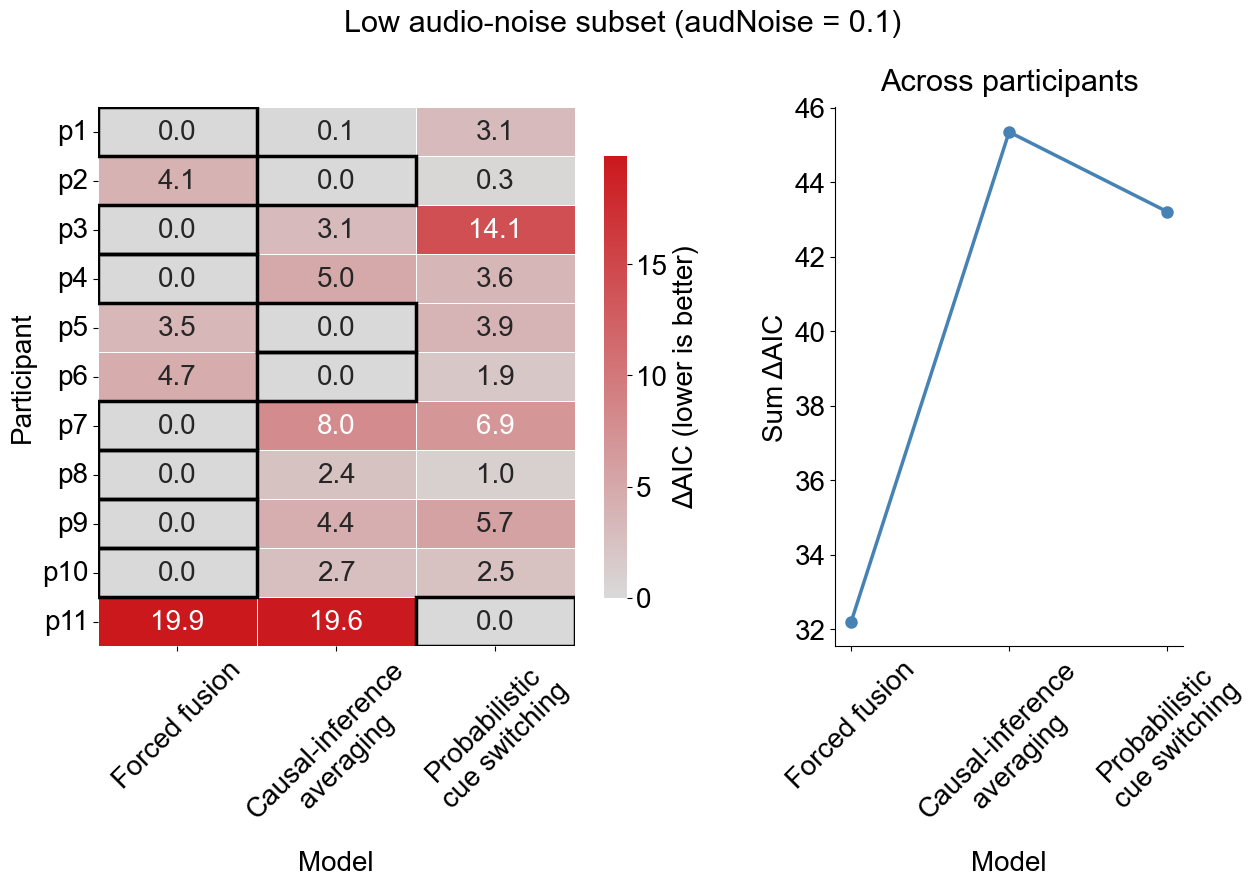

Best-model counts (n=11):
modelType
Forced fusion                  7
Causal-inference averaging     3
Probabilistic cue switching    1
Name: count, dtype: int64


In [12]:
HEATMAP_CMAP = sns.blend_palette(['#d9d9d9', '#cb181d'], as_cmap=True)
FONT_SIZE = 20


def wrap_label(text, max_chars=15):
    words = text.split()
    if not words:
        return text
    lines = [words[0]]
    for word in words[1:]:
        candidate = f"{lines[-1]} {word}"
        if len(candidate) <= max_chars:
            lines[-1] = candidate
        else:
            lines.append(word)
    return '\n'.join(lines)


def prepare_comparison(df_results, compBase='AIC'):
    df = df_results.copy()
    df[compBase] = pd.to_numeric(df[compBase], errors='coerce')
    df = df.dropna(subset=[compBase])
    df['delta'] = df.groupby('participantID')[compBase].transform(lambda x: x - x.min())

    participant_order = sorted(df['participantID'].unique())
    heat = df.pivot(index='participantID', columns='modelType', values='delta').reindex(participant_order)
    ordered = [m for m in MODEL_ORDER if m in heat.columns]
    heat = heat[ordered]

    best_rows = df.loc[df.groupby('participantID')[compBase].idxmin()].set_index('participantID').reindex(participant_order)
    return {
        'heat': heat,
        'model_sums': heat.sum(axis=0).reindex(ordered),
        'best_rows': best_rows,
        'participant_display_labels': {p: f'p{i}' for i, p in enumerate(participant_order, start=1)},
        'best_model_counts': best_rows['modelType'].value_counts(),
        'participant_order': participant_order,
    }


def plot_single_panel(df_results, panel_title, compBase='AIC', save_path=None):
    comp = prepare_comparison(df_results, compBase=compBase)
    heat = comp['heat']
    best_rows = comp['best_rows']
    labels = comp['participant_display_labels']
    sums = comp['model_sums']

    fig, (ax_heat, ax_sum) = plt.subplots(
        1, 2, figsize=(14, 7),
        gridspec_kw={'width_ratios': [2.4, 1.4], 'wspace': 0.3},
    )
    fig.patch.set_facecolor('white')

    finite = heat.to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    vmax = max(float(finite.max()) if finite.size else 1.0, 1.0)

    hm = sns.heatmap(
        heat, annot=True, fmt='.1f', cmap=HEATMAP_CMAP, vmin=0, vmax=vmax,
        linewidths=0.5, linecolor='white', ax=ax_heat, cbar=True,
        cbar_kws={'label': f'Δ{compBase} (lower is better)', 'shrink': 0.82},
        annot_kws={'fontsize': FONT_SIZE},
    )
    cbar = hm.collections[0].colorbar
    cbar.set_label(f'Δ{compBase} (lower is better)', fontsize=FONT_SIZE)
    cbar.ax.tick_params(labelsize=FONT_SIZE)

    ax_heat.set_xlabel('Model', fontsize=FONT_SIZE)
    ax_heat.set_ylabel('Participant', fontsize=FONT_SIZE)
    ax_heat.set_xticklabels([wrap_label(t.get_text()) for t in ax_heat.get_xticklabels()],
                            rotation=45, ha='center', fontsize=FONT_SIZE)
    ax_heat.set_yticklabels([labels[p] for p in heat.index], rotation=0, fontsize=FONT_SIZE)

    cols = heat.columns.tolist()
    for row_idx, pid in enumerate(heat.index):
        best = best_rows.loc[pid, 'modelType']
        if pd.notna(best) and best in cols:
            ax_heat.add_patch(plt.Rectangle((cols.index(best), row_idx), 1, 1,
                                            fill=False, edgecolor='black', lw=2.5))

    ax_sum.plot(range(len(sums)), sums.values, marker='o', linestyle='-',
                linewidth=2.5, markersize=8, color='steelblue')
    ax_sum.set_xticks(range(len(sums)))
    ax_sum.set_xticklabels([wrap_label(m) for m in sums.index],
                           rotation=45, ha='center', fontsize=FONT_SIZE)
    ax_sum.set_xlabel('Model', fontsize=FONT_SIZE)
    ax_sum.set_ylabel(f'Sum Δ{compBase}', fontsize=FONT_SIZE)
    ax_sum.set_title('Across participants', fontsize=FONT_SIZE + 2, pad=12)
    ax_sum.tick_params(axis='y', labelsize=FONT_SIZE)
    ax_sum.spines['top'].set_visible(False)
    ax_sum.spines['right'].set_visible(False)

    fig.suptitle(panel_title, fontsize=FONT_SIZE + 2, y=1.02)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()

    n = len(comp['participant_order'])
    print(f"Best-model counts (n={n}):")
    print(comp['best_model_counts'])
    return comp


comp_low = plot_single_panel(
    df_low,
    panel_title=PANEL_TITLE,
    compBase='AIC',
    save_path=f'modelComparison_{FIG_TAG}.pdf',
)

## 5. Random-effects Bayesian model selection (Stephan 2009 + Rigoux 2014)

In [7]:
def build_log_evidence_matrix(df_results, models_ordered):
    participants = sorted(df_results['participantID'].unique())
    K = len(models_ordered)
    N = len(participants)
    L = np.full((N, K), -np.inf)
    for i, pid in enumerate(participants):
        for j, mod in enumerate(models_ordered):
            row = df_results[(df_results['participantID'] == pid) & (df_results['modelType'] == mod)]
            if len(row) == 1:
                L[i, j] = -0.5 * row['AIC'].values[0]
    return L, participants


def spm_BMS_vb(L, alpha0=None, max_iter=500, tol=1e-6):
    N, K = L.shape
    if alpha0 is None:
        alpha0 = np.ones(K)
    L = L - L.max(axis=1, keepdims=True)
    alpha = alpha0.copy()
    for _ in range(max_iter):
        psi_sum = digamma(alpha.sum())
        log_u = digamma(alpha) - psi_sum
        log_g = L + log_u[np.newaxis, :]
        log_g = log_g - log_g.max(axis=1, keepdims=True)
        g = np.exp(log_g)
        g = g / g.sum(axis=1, keepdims=True)
        alpha_new = alpha0 + g.sum(axis=0)
        if np.max(np.abs(alpha_new - alpha)) < tol:
            alpha = alpha_new
            break
        alpha = alpha_new
    r = alpha / alpha.sum()
    samples = dirichlet_dist.rvs(alpha, size=1_000_000)
    xp = (samples.argmax(axis=1)[:, None] == np.arange(K)[None, :]).mean(axis=0)
    return alpha, r, xp


def _free_energy(L, alpha, alpha0):
    psi_sum = digamma(alpha.sum())
    log_u = digamma(alpha) - psi_sum
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    E_ll = np.sum(g * L)
    H_g = -np.sum(g * np.log(g))
    KL = (gammaln(alpha.sum()) - gammaln(alpha0.sum())
          + np.sum(gammaln(alpha0) - gammaln(alpha))
          + np.sum((alpha - alpha0) * (digamma(alpha) - psi_sum)))
    return E_ll + H_g - KL


def _free_energy_null(L, alpha0):
    K = L.shape[1]
    log_u = np.log(np.ones(K) / K)
    L_stable = L - L.max(axis=1, keepdims=True)
    log_g = L_stable + log_u[np.newaxis, :]
    log_g = log_g - log_g.max(axis=1, keepdims=True)
    g = np.exp(log_g); g = g / g.sum(axis=1, keepdims=True); g = np.clip(g, 1e-300, None)
    return np.sum(g * L) - np.sum(g * np.log(g))


def bayesian_omnibus_risk(L, alpha0=None):
    if alpha0 is None:
        alpha0 = np.ones(L.shape[1])
    alpha_fit, _, _ = spm_BMS_vb(L, alpha0=alpha0)
    F1 = _free_energy(L, alpha_fit, alpha0)
    F0 = _free_energy_null(L, alpha0)
    return 1.0 / (1.0 + np.exp(F1 - F0))


def run_bms(df_results, models_ordered, label=''):
    L, pids = build_log_evidence_matrix(df_results, models_ordered)
    alpha_post, r_freq, xp = spm_BMS_vb(L)
    bor = bayesian_omnibus_risk(L)
    pxp = xp * (1 - bor) + bor / len(models_ordered)
    print(f"\n{'=' * 64}\nRandom-effects BMS {label}\n{'=' * 64}")
    print(f"N = {len(pids)} participants, K = {len(models_ordered)} models\n")
    print(f"{'Model':<32s} {'E[r]':>8s} {'XP':>8s} {'PXP':>8s}")
    print('-' * 60)
    for j, mod in enumerate(models_ordered):
        print(f"{mod:<32s} {r_freq[j]:8.3f} {xp[j]:8.3f} {pxp[j]:8.3f}")
    print('-' * 60)
    print(f"BOR = {bor:.3f}")
    return {'alpha': alpha_post, 'r': r_freq, 'xp': xp, 'pxp': pxp, 'bor': bor,
            'models': models_ordered, 'participants': pids}


bms_low = run_bms(df_low, MODEL_ORDER, label=f'({NOISE_LABEL} noise)')


Random-effects BMS (low noise)
N = 11 participants, K = 3 models

Model                                E[r]       XP      PXP
------------------------------------------------------------
Forced fusion                       0.543    0.862    0.419
Causal-inference averaging          0.240    0.079    0.292
Probabilistic cue switching         0.217    0.059    0.289
------------------------------------------------------------
BOR = 0.839


## 6. PXP plot

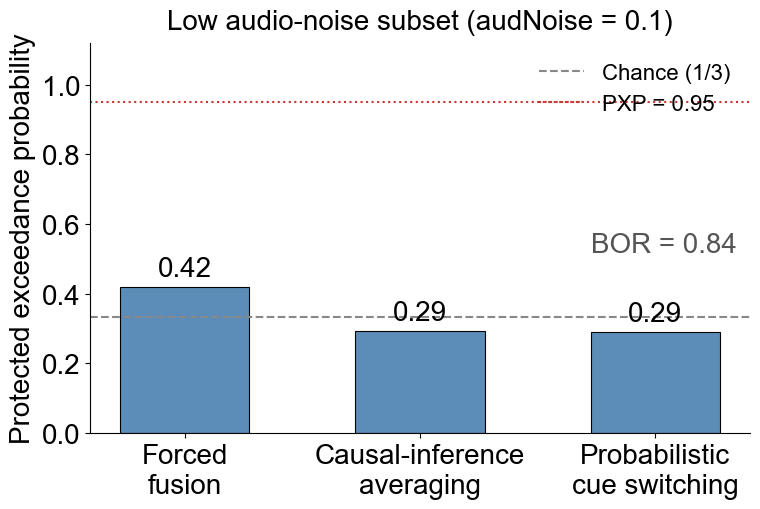

In [8]:
def plot_pxp(bms_result, title_suffix='', save_path=None):
    plt.rcParams.update({
        'font.size': 20, 'font.weight': 'normal',
        'axes.labelweight': 'normal', 'axes.titleweight': 'normal',
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    })
    K = len(bms_result['models'])
    pxp = bms_result['pxp']
    short = [m.replace(' ', '\n', 1) for m in bms_result['models']]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    bars = ax.bar(np.arange(K), pxp, width=0.55, color='#5b8db8',
                  edgecolor='black', linewidth=0.8)
    ax.axhline(1 / K, color='#888888', linestyle='--', linewidth=1.5, label=f'Chance (1/{K})')
    ax.axhline(0.95, color='#cc3333', linestyle=':', linewidth=1.5, label='PXP = 0.95')
    for bar, val in zip(bars, pxp):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=20)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(short, fontsize=20)
    ax.set_ylabel('Protected exceedance probability', fontsize=20)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='y', labelsize=20)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.text(0.98, 0.45, f"BOR = {bms_result['bor']:.2f}", transform=ax.transAxes,
            ha='right', va='bottom', fontsize=20, color='#555555')
    if title_suffix:
        ax.set_title(title_suffix, fontsize=20, pad=10)
    ax.legend(fontsize=16, frameon=False, loc='upper right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=900, bbox_inches='tight')
        plt.savefig(save_path.replace('.pdf', '.svg'), format='svg', bbox_inches='tight')
    plt.show()


plot_pxp(bms_low, title_suffix=PANEL_TITLE, save_path=f'pxp_{FIG_TAG}.pdf')

## 7. Compact per-participant table

In [9]:
def comparison_table(df_results):
    df = df_results.copy()
    df['deltaAIC'] = df.groupby('participantID')['AIC'].transform(lambda x: x - x.min())
    df['deltaBIC'] = df.groupby('participantID')['BIC'].transform(lambda x: x - x.min())
    pivot = df.pivot_table(index='participantID', columns='modelType',
                            values=['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'])
    pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
        [['logLikelihood', 'AIC', 'deltaAIC', 'BIC', 'deltaBIC'], MODEL_ORDER]
    ))
    return pivot


low_table = comparison_table(df_low)
print(f'{NOISE_LABEL.capitalize()} noise — per-participant comparison')
print(low_table.round(2))

Low noise — per-participant comparison
              logLikelihood                             \
              Forced fusion Causal-inference averaging   
participantID                                            
as                  -498.31                    -497.37   
dt                  -598.93                    -595.89   
hh                  -273.78                    -274.31   
ip                  -538.65                    -540.15   
ln2                 -469.81                    -467.04   
mh                  -612.23                    -608.87   
ml                  -570.44                    -573.45   
mt                  -496.89                    -497.09   
oy                  -550.24                    -551.45   
qs                  -543.81                    -544.18   
sx                  -541.27                    -540.12   

                                                    AIC  \
              Probabilistic cue switching Forced fusion   
participantID                 